# Notebook 04 — Normalización *train-only* de LST e índices espectrales

Este notebook implementa la normalización usada para el flujo de modelado LST/SUHI de Barranquilla.

## Objetivo

Estimar parámetros de normalización exclusivamente con el periodo de entrenamiento y aplicarlos de forma fija a todos los años operativos.

## Periodo operativo

- Años: 2013–2025
- Entrenamiento para estimar parámetros: 2013–2019
- Validación: 2020–2022
- Prueba: 2023–2025

## Estrategia

- **LST**: normalización global tipo z-score usando media y desviación estándar estimadas solo con TRAIN.
- **Índices espectrales**: escalamiento robusto min–max al intervalo [0, 1] usando percentiles P2.5 y P97.5 estimados solo con TRAIN.
- **n_obs**: se conserva sin normalizar, como variable auxiliar de auditoría.

## Entradas principales

Productos V6 generados por `03_quality_control.ipynb`:

```text
03_annual_raw_composites/v6_common_valid_mask/
```

Máscara espacial de entrenamiento:

```text
01_aoi_reference/train_spatial_mask/train_spatial_mask.tif
```

Referencia geométrica oficial:

```text
01_aoi_reference/reference_grid/model_domain_reference.tif
```

## Salidas principales

Productos raster normalizados externos:

```text
05_normalized_products/v6_train_only_mixed_strategy/
```

Reportes livianos:

```text
00_documentation/quality_control/04_train_only_normalization_2013_2025/
```

Las salidas raster pesadas no deben subirse a GitHub. Solo deben subirse los CSV/JSON livianos y figuras diagnósticas.

In [1]:
# ============================================================
# CELDA 1 — Montar Google Drive e importar librerías
# ============================================================

from pathlib import Path
import json
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import rasterio
except ImportError as exc:
    raise ImportError(
        "No se encontró rasterio. En Colab puedes instalarlo con: !pip install rasterio"
    ) from exc

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    warnings.warn(f"No se montó Google Drive automáticamente: {exc}")

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)


Mounted at /content/drive


In [2]:
# ============================================================
# CELDA 2 — Configuración general del proyecto
# ============================================================

START_YEAR = 2013
END_YEAR = 2025
YEARS_ALL = list(range(START_YEAR, END_YEAR + 1))

YEARS_TRAIN = list(range(2013, 2020))       # 2013–2019
YEARS_VALIDATION = list(range(2020, 2023))  # 2020–2022
YEARS_TEST = list(range(2023, 2026))        # 2023–2025

SPECTRAL_VARS = ["NDVI", "NDMI", "NDBI", "UI", "SAVI", "BSI"]
TARGET_VAR = "LST"
CONTINUOUS_VARS = SPECTRAL_VARS + [TARGET_VAR]
NOBS_VARS = ["n_obs_indices", "n_obs_LST"]

ROBUST_P_LOW = 2.5
ROBUST_P_HIGH = 97.5
NODATA_FLOAT = -9999.0

PROJECT_CANDIDATES = [
    Path('/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling'),
    Path('/content/drive/MyDrive/Barranquilla_LST_2013_2025_Modeling'),
]

PROJECT_DIR = None
for candidate in PROJECT_CANDIDATES:
    if candidate.exists():
        PROJECT_DIR = candidate
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "No se encontró la carpeta del proyecto en Google Drive. "
        "Verifica que Drive esté montado y que exista Barranquilla_LST_2013_2026_Modeling."
    )

V6_DIR = PROJECT_DIR / '03_annual_raw_composites' / 'v6_common_valid_mask'
NORM_DIR = PROJECT_DIR / '05_normalized_products' / 'v6_train_only_mixed_strategy'
PARAMS_DIR = NORM_DIR / '_normalization_params'
REPORT_DIR = PROJECT_DIR / '00_documentation' / 'quality_control' / '04_train_only_normalization_2013_2025'
FIG_DIR = REPORT_DIR / 'figures'

TRAIN_SPATIAL_MASK = PROJECT_DIR / '01_aoi_reference' / 'train_spatial_mask' / 'train_spatial_mask.tif'
MODEL_DOMAIN_REFERENCE = PROJECT_DIR / '01_aoi_reference' / 'reference_grid' / 'model_domain_reference.tif'

for d in [NORM_DIR, PARAMS_DIR, REPORT_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('PROJECT_DIR:', PROJECT_DIR)
print('V6_DIR:', V6_DIR)
print('NORM_DIR:', NORM_DIR)
print('REPORT_DIR:', REPORT_DIR)
print('FIG_DIR:', FIG_DIR)
print('Años:', YEARS_ALL)
print('TRAIN:', YEARS_TRAIN)
print('VALIDATION:', YEARS_VALIDATION)
print('TEST:', YEARS_TEST)


PROJECT_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling
V6_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/03_annual_raw_composites/v6_common_valid_mask
NORM_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/05_normalized_products/v6_train_only_mixed_strategy
REPORT_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025
FIG_DIR: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/figures
Años: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
TRAIN: [2013, 2014, 2015, 2016, 2017, 2018, 2019]
VALIDATION: [2020, 2021, 2022]
TEST: [2023, 2024, 2025]


In [3]:
# ============================================================
# CELDA 3 — Funciones auxiliares de rutas y lectura raster
# ============================================================

def v6_path(var, year):
    # Ruta esperada de producto V6 generado por Notebook 03.
    if var == 'LST':
        return V6_DIR / f'EXP10Bv6_LST_median_{year}.tif'
    if var in SPECTRAL_VARS:
        return V6_DIR / f'EXP10Bv6_{var}_median_{year}.tif'
    if var == 'n_obs_indices':
        return V6_DIR / f'EXP10Bv6_n_obs_indices_{year}.tif'
    if var == 'n_obs_LST':
        return V6_DIR / f'EXP10Bv6_n_obs_LST_{year}.tif'
    raise ValueError(f'Variable no reconocida: {var}')


def normalized_path(var, year):
    # Ruta de producto normalizado EXP10C.
    if var == 'LST':
        return NORM_DIR / f'EXP10C_LST_zscore_train_{year}.tif'
    if var in SPECTRAL_VARS:
        return NORM_DIR / f'EXP10C_{var}_robust01_train_{year}.tif'
    raise ValueError(f'Variable continua no reconocida: {var}')


def nobs_out_path(var, year):
    # Ruta de n_obs copiado sin normalización.
    if var == 'n_obs_indices':
        return NORM_DIR / f'EXP10C_n_obs_indices_{year}.tif'
    if var == 'n_obs_LST':
        return NORM_DIR / f'EXP10C_n_obs_LST_{year}.tif'
    raise ValueError(f'Variable n_obs no reconocida: {var}')


def read_float_array(path):
    # Lee un raster como float32 y convierte NoData a NaN.
    path = Path(path)
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float32')
        nodata = src.nodata
        profile = src.profile.copy()
        shape = (src.height, src.width)
        crs = src.crs
        transform = src.transform
    if nodata is not None:
        arr[arr == nodata] = np.nan
    arr[arr == NODATA_FLOAT] = np.nan
    arr[~np.isfinite(arr)] = np.nan
    return arr, profile, shape, crs, transform


def write_float_raster(path, array, profile, nodata=NODATA_FLOAT):
    # Escribe un raster float32 comprimido usando NoData explícito.
    out = np.where(np.isfinite(array), array, nodata).astype('float32')
    profile_out = profile.copy()
    profile_out.update(dtype='float32', nodata=nodata, compress='deflate')
    with rasterio.open(path, 'w', **profile_out) as dst:
        dst.write(out, 1)


def safe_stats(values):
    # Estadísticos básicos seguros para vectores válidos.
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return {'n_valid': 0, 'min': np.nan, 'p01': np.nan, 'p05': np.nan,
                'p50': np.nan, 'mean': np.nan, 'p95': np.nan, 'p99': np.nan, 'max': np.nan}
    return {
        'n_valid': int(values.size),
        'min': float(np.nanmin(values)),
        'p01': float(np.nanpercentile(values, 1)),
        'p05': float(np.nanpercentile(values, 5)),
        'p50': float(np.nanpercentile(values, 50)),
        'mean': float(np.nanmean(values)),
        'p95': float(np.nanpercentile(values, 95)),
        'p99': float(np.nanpercentile(values, 99)),
        'max': float(np.nanmax(values)),
    }


In [4]:
# ============================================================
# CELDA 4 — Verificación de entradas V6 y referencia geométrica
# ============================================================

required_paths = [TRAIN_SPATIAL_MASK, MODEL_DOMAIN_REFERENCE]
for year in YEARS_ALL:
    for var in CONTINUOUS_VARS + NOBS_VARS:
        required_paths.append(v6_path(var, year))

missing = [str(p) for p in required_paths if not Path(p).exists()]
print('Archivos requeridos:', len(required_paths))
print('Archivos faltantes :', len(missing))

if missing:
    print('Ejemplos de faltantes:')
    for m in missing[:30]:
        print(' -', m)
    raise FileNotFoundError('Faltan entradas para normalización. Revisa V6 y las rutas de referencia.')

with rasterio.open(MODEL_DOMAIN_REFERENCE) as ref:
    ref_shape = (ref.height, ref.width)
    ref_crs = ref.crs
    ref_transform = ref.transform

geom_rows = []
for year in YEARS_ALL:
    for var in CONTINUOUS_VARS + NOBS_VARS:
        p = v6_path(var, year)
        with rasterio.open(p) as src:
            shape = (src.height, src.width)
            crs = src.crs
            transform = src.transform
            nodata = src.nodata
        geom_ok = (shape == ref_shape and crs == ref_crs and transform == ref_transform)
        geom_rows.append({
            'year': year, 'var': var, 'file': p.name,
            'shape': str(shape), 'crs': str(crs), 'nodata': nodata,
            'shape_ok': shape == ref_shape,
            'crs_ok': crs == ref_crs,
            'transform_ok': transform == ref_transform,
            'geom_ok': geom_ok,
        })

geom_df = pd.DataFrame(geom_rows)
geom_csv = REPORT_DIR / '04_input_v6_geometry_audit_2013_2025.csv'
geom_df.to_csv(geom_csv, index=False)

display(geom_df.head())
print('Reporte geométrico:', geom_csv)

if not geom_df['geom_ok'].all():
    display(geom_df[geom_df['geom_ok'] == False])
    raise RuntimeError('Hay productos V6 con geometría inconsistente. No se debe normalizar.')

print('✅ Entradas V6 completas y geométricamente consistentes.')


Archivos requeridos: 119
Archivos faltantes : 0


,year,var,file,shape,crs,nodata,shape_ok,crs_ok,transform_ok,geom_ok
0,2013,NDVI,EXP10Bv6_NDVI_median_2013.tif,"(1115, 1257)",EPSG:32618,-9999.0,True,True,True,True
1,2013,NDMI,EXP10Bv6_NDMI_median_2013.tif,"(1115, 1257)",EPSG:32618,-9999.0,True,True,True,True
2,2013,NDBI,EXP10Bv6_NDBI_median_2013.tif,"(1115, 1257)",EPSG:32618,-9999.0,True,True,True,True
3,2013,UI,EXP10Bv6_UI_median_2013.tif,"(1115, 1257)",EPSG:32618,-9999.0,True,True,True,True
4,2013,SAVI,EXP10Bv6_SAVI_median_2013.tif,"(1115, 1257)",EPSG:32618,-9999.0,True,True,True,True


Reporte geométrico: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/04_input_v6_geometry_audit_2013_2025.csv
✅ Entradas V6 completas y geométricamente consistentes.


In [5]:
# ============================================================
# CELDA 5 — Leer y validar máscara espacial TRAIN
# ============================================================

with rasterio.open(TRAIN_SPATIAL_MASK) as src:
    train_mask_arr = src.read(1)
    train_shape = (src.height, src.width)
    train_crs = src.crs
    train_transform = src.transform
    train_nodata = src.nodata

if train_shape != ref_shape or train_crs != ref_crs or train_transform != ref_transform:
    raise ValueError(
        'train_spatial_mask no coincide con la referencia geométrica oficial.\n'
        f'train_shape={train_shape}, ref_shape={ref_shape}\n'
        f'train_crs={train_crs}, ref_crs={ref_crs}\n'
        f'train_transform={train_transform}, ref_transform={ref_transform}'
    )

if train_nodata is not None:
    train_spatial = (train_mask_arr != train_nodata) & (train_mask_arr > 0)
else:
    train_spatial = train_mask_arr > 0

train_mask_summary = {
    'train_spatial_mask': str(TRAIN_SPATIAL_MASK),
    'n_pixels_total': int(train_spatial.size),
    'n_pixels_train_spatial': int(train_spatial.sum()),
    'pct_train_spatial': float(100 * train_spatial.sum() / train_spatial.size),
}

train_mask_summary_csv = REPORT_DIR / '04_train_spatial_mask_summary_2013_2025.csv'
pd.DataFrame([train_mask_summary]).to_csv(train_mask_summary_csv, index=False)

print('Máscara espacial TRAIN')
print('Píxeles TRAIN:', train_mask_summary['n_pixels_train_spatial'])
print('Porcentaje TRAIN:', f"{train_mask_summary['pct_train_spatial']:.2f}%")
print('Reporte:', train_mask_summary_csv)


Máscara espacial TRAIN
Píxeles TRAIN: 940645
Porcentaje TRAIN: 67.11%
Reporte: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/04_train_spatial_mask_summary_2013_2025.csv


In [6]:
# ============================================================
# CELDA 6 — Estimar parámetros de normalización TRAIN-only
# ============================================================

params = {}
param_rows = []

for var in SPECTRAL_VARS:
    print('\n' + '=' * 70)
    print(f'Estimando percentiles robustos TRAIN-only para {var}')
    print('=' * 70)
    train_values = []
    for year in YEARS_TRAIN:
        arr, *_ = read_float_array(v6_path(var, year))
        valid = np.isfinite(arr) & train_spatial
        vals = arr[valid].astype('float32')
        if vals.size == 0:
            raise ValueError(f'No hay valores válidos TRAIN para {var} en {year}')
        train_values.append(vals)
        print(f'{year} | n={vals.size:,} | p50={np.nanpercentile(vals, 50):.6f}')

    train_values = np.concatenate(train_values)
    p_low_value = float(np.nanpercentile(train_values, ROBUST_P_LOW))
    p_high_value = float(np.nanpercentile(train_values, ROBUST_P_HIGH))
    robust_range = p_high_value - p_low_value

    if not np.isfinite(p_low_value) or not np.isfinite(p_high_value):
        raise ValueError(f'Percentiles no finitos para {var}')
    if robust_range <= 0:
        raise ValueError(f'Rango robusto inválido para {var}: {p_low_value}, {p_high_value}')

    stats = safe_stats(train_values)
    params[var] = {
        'type': 'spectral_index',
        'method': 'robust_minmax_train_only',
        'train_years': YEARS_TRAIN,
        'spatial_mask': str(TRAIN_SPATIAL_MASK),
        'p_low': ROBUST_P_LOW,
        'p_high': ROBUST_P_HIGH,
        'value_low_train': p_low_value,
        'value_high_train': p_high_value,
        'range_train': robust_range,
        'clip_output_to_0_1': True,
        'n_train_values': int(train_values.size),
        'min_train_raw': stats['min'], 'p01_train_raw': stats['p01'],
        'p05_train_raw': stats['p05'], 'p50_train_raw': stats['p50'],
        'mean_train_raw': stats['mean'], 'p95_train_raw': stats['p95'],
        'p99_train_raw': stats['p99'], 'max_train_raw': stats['max'],
    }
    param_rows.append({'var': var, **params[var]})
    print(f'P{ROBUST_P_LOW}_train : {p_low_value:.6f}')
    print(f'P{ROBUST_P_HIGH}_train: {p_high_value:.6f}')
    print(f'Rango robusto: {robust_range:.6f}')

print('\n' + '=' * 70)
print('Estimando media y desviación estándar TRAIN-only para LST')
print('=' * 70)

lst_train_values = []
for year in YEARS_TRAIN:
    arr, *_ = read_float_array(v6_path('LST', year))
    valid = np.isfinite(arr) & train_spatial
    vals = arr[valid].astype('float32')
    if vals.size == 0:
        raise ValueError(f'No hay valores válidos TRAIN para LST en {year}')
    lst_train_values.append(vals)
    print(f'{year} | n={vals.size:,} | mean={np.nanmean(vals):.6f} | std={np.nanstd(vals):.6f}')

lst_train_values = np.concatenate(lst_train_values)
lst_mean = float(np.nanmean(lst_train_values))
lst_std = float(np.nanstd(lst_train_values, ddof=0))

if not np.isfinite(lst_mean) or not np.isfinite(lst_std) or lst_std <= 0:
    raise ValueError(f'Parámetros LST inválidos: mean={lst_mean}, std={lst_std}')

lst_stats = safe_stats(lst_train_values)
params['LST'] = {
    'type': 'target',
    'method': 'zscore_train_only',
    'train_years': YEARS_TRAIN,
    'spatial_mask': str(TRAIN_SPATIAL_MASK),
    'mean_train': lst_mean,
    'std_train': lst_std,
    'n_train_values': int(lst_train_values.size),
    'min_train_raw': lst_stats['min'], 'p01_train_raw': lst_stats['p01'],
    'p05_train_raw': lst_stats['p05'], 'p50_train_raw': lst_stats['p50'],
    'mean_train_raw': lst_stats['mean'], 'p95_train_raw': lst_stats['p95'],
    'p99_train_raw': lst_stats['p99'], 'max_train_raw': lst_stats['max'],
}
param_rows.append({'var': 'LST', **params['LST']})

params_df = pd.DataFrame(param_rows)
params_csv = PARAMS_DIR / '04_normalization_parameters_train_only_2013_2025.csv'
params_json = PARAMS_DIR / '04_normalization_parameters_train_only_2013_2025.json'
params_report_csv = REPORT_DIR / '04_normalization_parameters_train_only_2013_2025.csv'
params_report_json = REPORT_DIR / '04_normalization_parameters_train_only_2013_2025.json'
params_df.to_csv(params_csv, index=False)
params_df.to_csv(params_report_csv, index=False)
for json_path in [params_json, params_report_json]:
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(params, f, indent=2, ensure_ascii=False)

print('\n✅ Parámetros de normalización guardados.')
print(params_csv)
print(params_json)
print(params_report_csv)
print(params_report_json)
display(params_df)



Estimando percentiles robustos TRAIN-only para NDVI
2013 | n=613,613 | p50=0.666952
2014 | n=614,379 | p50=0.470563
2015 | n=614,496 | p50=0.482268
2016 | n=614,936 | p50=0.592729
2017 | n=614,806 | p50=0.600180
2018 | n=614,523 | p50=0.560710
2019 | n=615,831 | p50=0.482534
P2.5_train : 0.144141
P97.5_train: 0.833484
Rango robusto: 0.689343

Estimando percentiles robustos TRAIN-only para NDMI
2013 | n=613,613 | p50=0.227135
2014 | n=614,379 | p50=0.030551
2015 | n=614,496 | p50=0.034118
2016 | n=614,936 | p50=0.150348
2017 | n=614,806 | p50=0.150520
2018 | n=614,523 | p50=0.115857
2019 | n=615,831 | p50=0.045069
P2.5_train : -0.111807
P97.5_train: 0.461716
Rango robusto: 0.573523

Estimando percentiles robustos TRAIN-only para NDBI
2013 | n=613,613 | p50=-0.227135
2014 | n=614,379 | p50=-0.030551
2015 | n=614,496 | p50=-0.034118
2016 | n=614,936 | p50=-0.150348
2017 | n=614,806 | p50=-0.150520
2018 | n=614,523 | p50=-0.115857
2019 | n=615,831 | p50=-0.045069
P2.5_train : -0.461716
P9

,var,type,method,train_years,spatial_mask,p_low,p_high,value_low_train,value_high_train,range_train,clip_output_to_0_1,n_train_values,min_train_raw,p01_train_raw,p05_train_raw,p50_train_raw,mean_train_raw,p95_train_raw,p99_train_raw,max_train_raw,mean_train,std_train
0,NDVI,spectral_index,robust_minmax_train_only,"[2013, 2014, 2015, 2016, 2017, 2018, 2019]",/content/drive/MyDrive/Barranquilla_LST_2013_2...,2.5,97.5,0.144141,0.833484,0.689343,True,4302584,-0.283666,0.104468,0.182643,0.542215,0.520238,0.810357,0.853288,0.908128,NaN,NaN
1,NDMI,spectral_index,robust_minmax_train_only,"[2013, 2014, 2015, 2016, 2017, 2018, 2019]",/content/drive/MyDrive/Barranquilla_LST_2013_2...,2.5,97.5,-0.111807,0.461716,0.573523,True,4302584,-0.319361,-0.132039,-0.092968,0.101617,0.123903,0.404167,0.543501,0.757365,NaN,NaN
2,NDBI,spectral_index,robust_minmax_train_only,"[2013, 2014, 2015, 2016, 2017, 2018, 2019]",/content/drive/MyDrive/Barranquilla_LST_2013_2...,2.5,97.5,-0.461716,0.111807,0.573523,True,4302584,-0.757365,-0.543501,-0.404167,-0.101617,-0.123903,0.092968,0.132039,0.319361,NaN,NaN
3,UI,spectral_index,robust_minmax_train_only,"[2013, 2014, 2015, 2016, 2017, 2018, 2019]",/content/drive/MyDrive/Barranquilla_LST_2013_2...,2.5,97.5,-0.733780,0.005513,0.739293,True,4302584,-0.872574,-0.797981,-0.691880,-0.360718,-0.358530,-0.024699,0.037935,0.303078,NaN,NaN
4,SAVI,spectral_index,robust_minmax_train_only,"[2013, 2014, 2015, 2016, 2017, 2018, 2019]",/content/drive/MyDrive/Barranquilla_LST_2013_2...,2.5,97.5,0.098397,0.571602,0.473204,True,4302584,-0.118433,0.069200,0.125890,0.341972,0.337072,0.543785,0.601418,0.757729,NaN,NaN
5,BSI,spectral_index,robust_minmax_train_only,"[2013, 2014, 2015, 2016, 2017, 2018, 2019]",/content/drive/MyDrive/Barranquilla_LST_2013_2...,2.5,97.5,-0.378646,0.149055,0.527700,True,4302584,-0.593786,-0.459796,-0.331357,-0.029571,-0.056317,0.135518,0.163496,0.296726,NaN,NaN
6,LST,target,zscore_train_only,"[2013, 2014, 2015, 2016, 2017, 2018, 2019]",/content/drive/MyDrive/Barranquilla_LST_2013_2...,NaN,NaN,NaN,NaN,NaN,NaN,4302584,17.162910,29.766859,31.831343,38.475975,38.480301,44.869381,47.144073,53.901497,38.480301,4.035928


In [7]:
# ============================================================
# CELDA 7 — Aplicar normalización a todos los años 2013–2025
# ============================================================

audit_rows = []
for year in YEARS_ALL:
    print('\n' + '=' * 70)
    print(f'Normalizando año {year}')
    print('=' * 70)
    for var in CONTINUOUS_VARS:
        src_path = v6_path(var, year)
        dst_path = normalized_path(var, year)
        arr, profile, *_ = read_float_array(src_path)
        valid = np.isfinite(arr)
        norm = np.full(arr.shape, np.nan, dtype='float32')
        if var in SPECTRAL_VARS:
            p_low = params[var]['value_low_train']
            robust_range = params[var]['range_train']
            norm[valid] = (arr[valid] - p_low) / robust_range
            norm[valid] = np.clip(norm[valid], 0.0, 1.0)
            method = 'robust_minmax_train_only_clipped_0_1'
        elif var == 'LST':
            mean_train = params['LST']['mean_train']
            std_train = params['LST']['std_train']
            norm[valid] = (arr[valid] - mean_train) / std_train
            method = 'zscore_train_only'
        else:
            raise ValueError(var)

        write_float_raster(dst_path, norm, profile)
        vals_norm = norm[np.isfinite(norm)]
        stats = safe_stats(vals_norm)
        row = {
            'year': year,
            'split_role': 'train' if year in YEARS_TRAIN else ('validation' if year in YEARS_VALIDATION else 'test'),
            'var': var,
            'src_file': src_path.name,
            'dst_file': dst_path.name,
            'method': method,
            'pct_valid': float(100 * stats['n_valid'] / norm.size),
            'expected_output_range': '[0,1]' if var in SPECTRAL_VARS else 'unbounded_zscore',
        }
        row.update({f'norm_{k}': v for k, v in stats.items()})
        audit_rows.append(row)
        print(f'{var:5s} -> {dst_path.name} | n={stats["n_valid"]:,} | min={stats["min"]:.4f} | p50={stats["p50"]:.4f} | max={stats["max"]:.4f}')

print('\n✅ Variables continuas normalizadas.')



Normalizando año 2013
NDVI  -> EXP10C_NDVI_robust01_train_2013.tif | n=903,715 | min=0.0000 | p50=0.7851 | max=1.0000
NDMI  -> EXP10C_NDMI_robust01_train_2013.tif | n=903,715 | min=0.0000 | p50=0.6220 | max=1.0000
NDBI  -> EXP10C_NDBI_robust01_train_2013.tif | n=903,715 | min=0.0000 | p50=0.3780 | max=1.0000
UI    -> EXP10C_UI_robust01_train_2013.tif | n=903,715 | min=0.0000 | p50=0.2806 | max=1.0000
SAVI  -> EXP10C_SAVI_robust01_train_2013.tif | n=903,715 | min=0.0000 | p50=0.7272 | max=1.0000
BSI   -> EXP10C_BSI_robust01_train_2013.tif | n=903,715 | min=0.0000 | p50=0.3961 | max=1.0000
LST   -> EXP10C_LST_zscore_train_2013.tif | n=903,715 | min=-4.7064 | p50=-0.9759 | max=2.6031

Normalizando año 2014
NDVI  -> EXP10C_NDVI_robust01_train_2014.tif | n=905,317 | min=0.0000 | p50=0.5107 | max=1.0000
NDMI  -> EXP10C_NDMI_robust01_train_2014.tif | n=905,317 | min=0.0000 | p50=0.2774 | max=1.0000
NDBI  -> EXP10C_NDBI_robust01_train_2014.tif | n=905,317 | min=0.0000 | p50=0.7226 | max=1.000

In [8]:
# ============================================================
# CELDA 8 — Copiar n_obs sin normalizar
# ============================================================

for year in YEARS_ALL:
    for var in NOBS_VARS:
        src_path = v6_path(var, year)
        dst_path = nobs_out_path(var, year)
        if src_path.resolve() != dst_path.resolve():
            shutil.copy2(src_path, dst_path)
        arr, *_ = read_float_array(dst_path)
        valid = np.isfinite(arr) & (arr > 0)
        vals = arr[valid]
        stats = safe_stats(vals)
        row = {
            'year': year,
            'split_role': 'train' if year in YEARS_TRAIN else ('validation' if year in YEARS_VALIDATION else 'test'),
            'var': var,
            'src_file': src_path.name,
            'dst_file': dst_path.name,
            'method': 'copied_without_normalization',
            'pct_valid': float(100 * stats['n_valid'] / arr.size),
            'expected_output_range': 'observation_count',
        }
        row.update({f'norm_{k}': v for k, v in stats.items()})
        audit_rows.append(row)

print('✅ n_obs copiados sin normalizar.')


✅ n_obs copiados sin normalizar.


In [9]:
# ============================================================
# CELDA 9 — Auditoría de productos normalizados
# ============================================================

audit_df = pd.DataFrame(audit_rows)
audit_csv = REPORT_DIR / '04_normalization_audit_values_2013_2025.csv'
audit_df.to_csv(audit_csv, index=False)

expected_outputs = []
for year in YEARS_ALL:
    for var in CONTINUOUS_VARS:
        expected_outputs.append((year, var, normalized_path(var, year)))
    for var in NOBS_VARS:
        expected_outputs.append((year, var, nobs_out_path(var, year)))

file_rows = []
for year, var, path in expected_outputs:
    file_rows.append({
        'year': year, 'var': var, 'file': path.name, 'path': str(path),
        'exists': path.exists(),
        'size_mb': path.stat().st_size / (1024 ** 2) if path.exists() else np.nan,
    })
files_df = pd.DataFrame(file_rows)
files_csv = REPORT_DIR / '04_normalized_products_file_existence_2013_2025.csv'
files_df.to_csv(files_csv, index=False)

spectral_audit = audit_df[audit_df['var'].isin(SPECTRAL_VARS)].copy()
spectral_range_ok = ((spectral_audit['norm_min'] >= -1e-6) & (spectral_audit['norm_max'] <= 1.000001)).all()

lst_audit = audit_df[audit_df['var'] == 'LST'].copy()
train_lst = lst_audit[lst_audit['year'].isin(YEARS_TRAIN)]
summary = {
    'project_dir': str(PROJECT_DIR),
    'input_v6_dir': str(V6_DIR),
    'normalized_output_dir': str(NORM_DIR),
    'operational_period': f'{START_YEAR}-{END_YEAR}',
    'train_years': YEARS_TRAIN,
    'validation_years': YEARS_VALIDATION,
    'test_years': YEARS_TEST,
    'n_expected_outputs': len(expected_outputs),
    'n_existing_outputs': int(files_df['exists'].sum()),
    'all_outputs_exist': bool(files_df['exists'].all()),
    'spectral_indices_in_0_1': bool(spectral_range_ok),
    'lst_train_mean_of_year_means_after_zscore': float(train_lst['norm_mean'].mean()),
    'lst_train_median_of_year_medians_after_zscore': float(train_lst['norm_p50'].median()),
    'lst_normalization_method': 'zscore_train_only',
    'spectral_normalization_method': 'robust_minmax_train_only_p2_5_p97_5_clipped_0_1',
}
summary_csv = REPORT_DIR / '04_train_only_normalization_summary_2013_2025.csv'
summary_json = REPORT_DIR / '04_train_only_normalization_summary_2013_2025.json'
pd.DataFrame([summary]).to_csv(summary_csv, index=False)
with open(summary_json, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('Auditoría valores:', audit_csv)
print('Existencia productos:', files_csv)
print('Resumen CSV:', summary_csv)
print('Resumen JSON:', summary_json)
display(files_df.head())
display(audit_df.head())
display(pd.DataFrame([summary]))

if not files_df['exists'].all():
    display(files_df[files_df['exists'] == False])
    raise RuntimeError('Faltan productos normalizados.')
if not spectral_range_ok:
    display(spectral_audit[(spectral_audit['norm_min'] < -1e-6) | (spectral_audit['norm_max'] > 1.000001)])
    raise RuntimeError('Hay índices espectrales fuera de [0,1].')
print('✅ Auditoría aprobada: productos completos e índices en [0,1].')


Auditoría valores: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/04_normalization_audit_values_2013_2025.csv
Existencia productos: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/04_normalized_products_file_existence_2013_2025.csv
Resumen CSV: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/04_train_only_normalization_summary_2013_2025.csv
Resumen JSON: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/04_train_only_normalization_summary_2013_2025.json


,year,var,file,path,exists,size_mb
0,2013,NDVI,EXP10C_NDVI_robust01_train_2013.tif,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,2.809867
1,2013,NDMI,EXP10C_NDMI_robust01_train_2013.tif,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,2.894159
2,2013,NDBI,EXP10C_NDBI_robust01_train_2013.tif,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,2.923306
3,2013,UI,EXP10C_UI_robust01_train_2013.tif,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,2.938081
4,2013,SAVI,EXP10C_SAVI_robust01_train_2013.tif,/content/drive/MyDrive/Barranquilla_LST_2013_2...,True,2.768113


,year,split_role,var,src_file,dst_file,method,pct_valid,expected_output_range,norm_n_valid,norm_min,norm_p01,norm_p05,norm_p50,norm_mean,norm_p95,norm_p99,norm_max
0,2013,train,NDVI,EXP10Bv6_NDVI_median_2013.tif,EXP10C_NDVI_robust01_train_2013.tif,robust_minmax_train_only_clipped_0_1,64.479453,"[0,1]",903715,0.0,0.000000,0.137252,0.785119,0.699130,1.000000,1.000000,1.0
1,2013,train,NDMI,EXP10Bv6_NDMI_median_2013.tif,EXP10C_NDMI_robust01_train_2013.tif,robust_minmax_train_only_clipped_0_1,64.479453,"[0,1]",903715,0.0,0.011138,0.116116,0.622048,0.589189,1.000000,1.000000,1.0
2,2013,train,NDBI,EXP10Bv6_NDBI_median_2013.tif,EXP10C_NDBI_robust01_train_2013.tif,robust_minmax_train_only_clipped_0_1,64.479453,"[0,1]",903715,0.0,0.000000,0.000000,0.377952,0.410811,0.883884,0.988862,1.0
3,2013,train,UI,EXP10Bv6_UI_median_2013.tif,EXP10C_UI_robust01_train_2013.tif,robust_minmax_train_only_clipped_0_1,64.479453,"[0,1]",903715,0.0,0.000000,0.000000,0.280551,0.344794,0.877000,1.000000,1.0
4,2013,train,SAVI,EXP10Bv6_SAVI_median_2013.tif,EXP10C_SAVI_robust01_train_2013.tif,robust_minmax_train_only_clipped_0_1,64.479453,"[0,1]",903715,0.0,0.000000,0.132010,0.727214,0.664065,1.000000,1.000000,1.0


,project_dir,input_v6_dir,normalized_output_dir,operational_period,train_years,validation_years,test_years,n_expected_outputs,n_existing_outputs,all_outputs_exist,spectral_indices_in_0_1,lst_train_mean_of_year_means_after_zscore,lst_train_median_of_year_medians_after_zscore,lst_normalization_method,spectral_normalization_method
0,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,2013-2025,"[2013, 2014, 2015, 2016, 2017, 2018, 2019]","[2020, 2021, 2022]","[2023, 2024, 2025]",117,117,True,True,-0.184451,-0.073906,zscore_train_only,robust_minmax_train_only_p2_5_p97_5_clipped_0_1


✅ Auditoría aprobada: productos completos e índices en [0,1].


/tmp/ipykernel_19715/2429868840.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(lst_samples, labels=lst_labels, showfliers=False)


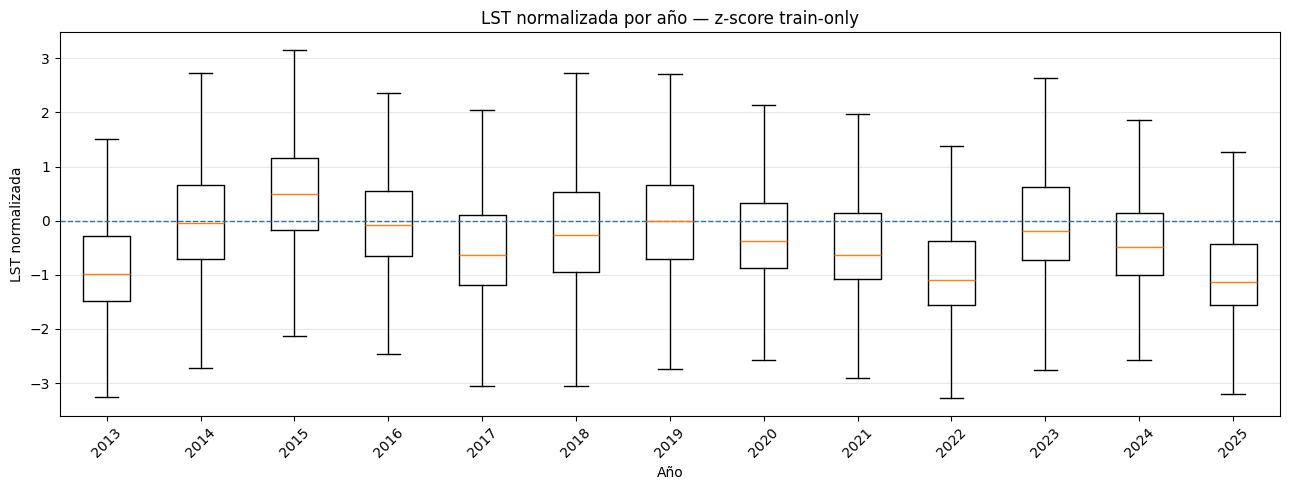

Figura guardada: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/figures/04_lst_zscore_boxplot_by_year_2013_2025.png


/tmp/ipykernel_19715/2429868840.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(spectral_samples, labels=spectral_labels, showfliers=False)


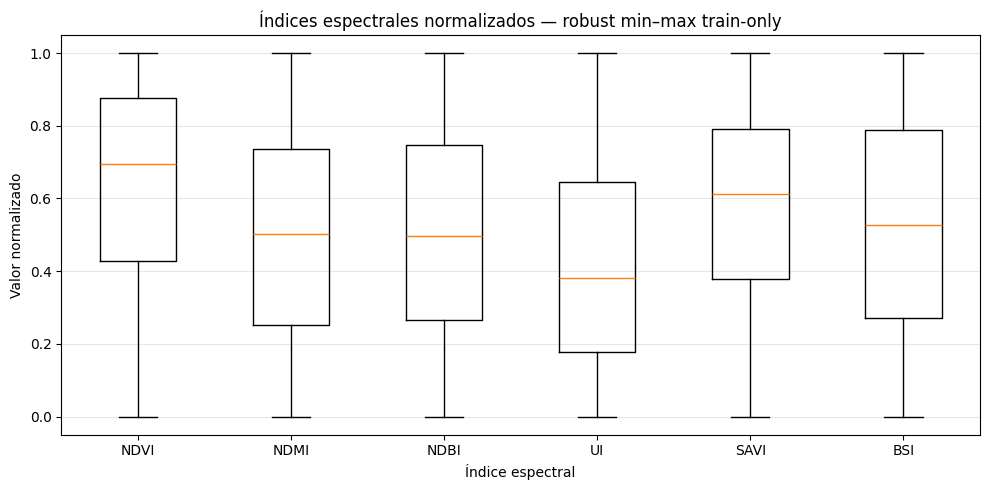

Figura guardada: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/figures/04_spectral_indices_robust01_boxplot_2013_2025.png


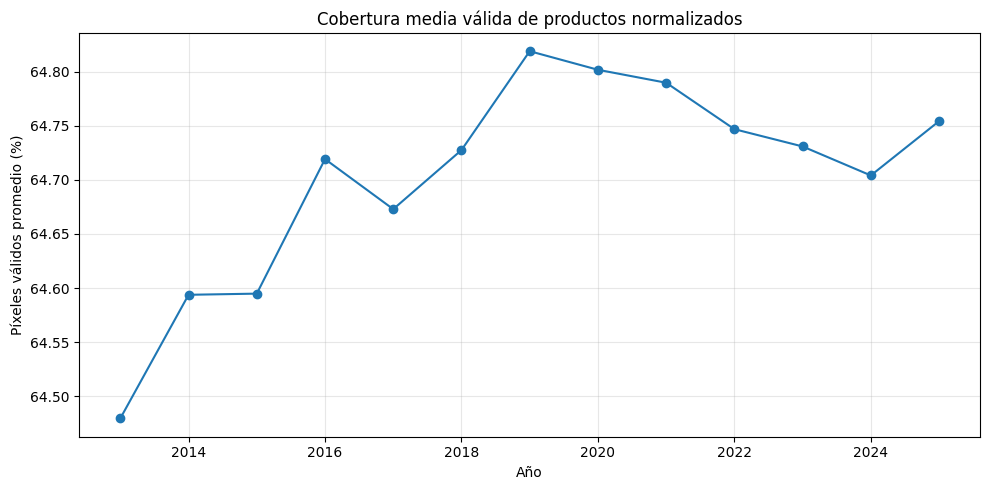

Figura guardada: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/figures/04_normalized_products_valid_coverage_2013_2025.png


,figure,path,description
0,04_lst_zscore_boxplot_by_year_2013_2025.png,/content/drive/MyDrive/Barranquilla_LST_2013_2...,Boxplot anual de LST normalizada mediante z-sc...
1,04_spectral_indices_robust01_boxplot_2013_2025...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,Boxplot de índices espectrales escalados con p...
2,04_normalized_products_valid_coverage_2013_202...,/content/drive/MyDrive/Barranquilla_LST_2013_2...,Cobertura media válida de productos normalizad...


Manifest de figuras: /content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/04_normalization_figures_manifest_2013_2025.csv


In [10]:
# ============================================================
# CELDA 10 — Figuras diagnósticas mínimas de normalización
# ============================================================

RANDOM_SEED = 42
MAX_SAMPLES_PER_FILE = 60000
rng = np.random.default_rng(RANDOM_SEED)

def sample_valid_values(path, max_samples=MAX_SAMPLES_PER_FILE):
    arr, *_ = read_float_array(path)
    vals = arr[np.isfinite(arr)]
    if vals.size == 0:
        return np.array([], dtype='float32')
    if vals.size > max_samples:
        idx = rng.choice(vals.size, size=max_samples, replace=False)
        vals = vals[idx]
    return vals.astype('float32')

# 10.1 Boxplot anual de LST normalizada
lst_samples = []
lst_labels = []
for year in YEARS_ALL:
    vals = sample_valid_values(normalized_path('LST', year), max_samples=MAX_SAMPLES_PER_FILE)
    if vals.size > 0:
        lst_samples.append(vals)
        lst_labels.append(str(year))

fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot(lst_samples, labels=lst_labels, showfliers=False)
ax.axhline(0, linestyle='--', linewidth=1)
ax.set_title('LST normalizada por año — z-score train-only')
ax.set_xlabel('Año')
ax.set_ylabel('LST normalizada')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
lst_fig = FIG_DIR / '04_lst_zscore_boxplot_by_year_2013_2025.png'
fig.savefig(lst_fig, dpi=200)
plt.show()
print('Figura guardada:', lst_fig)

# 10.2 Boxplot de índices normalizados por variable
spectral_samples = []
spectral_labels = []
for var in SPECTRAL_VARS:
    var_values = []
    for year in YEARS_ALL:
        vals = sample_valid_values(normalized_path(var, year), max_samples=15000)
        if vals.size > 0:
            var_values.append(vals)
    if var_values:
        spectral_samples.append(np.concatenate(var_values))
        spectral_labels.append(var)

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(spectral_samples, labels=spectral_labels, showfliers=False)
ax.set_ylim(-0.05, 1.05)
ax.set_title('Índices espectrales normalizados — robust min–max train-only')
ax.set_xlabel('Índice espectral')
ax.set_ylabel('Valor normalizado')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
spectral_fig = FIG_DIR / '04_spectral_indices_robust01_boxplot_2013_2025.png'
fig.savefig(spectral_fig, dpi=200)
plt.show()
print('Figura guardada:', spectral_fig)

# 10.3 Cobertura válida de productos normalizados por año
coverage_df = (
    audit_df[audit_df['var'].isin(CONTINUOUS_VARS)]
    .groupby('year', as_index=False)['pct_valid']
    .mean()
    .rename(columns={'pct_valid': 'mean_pct_valid_continuous_vars'})
)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(coverage_df['year'], coverage_df['mean_pct_valid_continuous_vars'], marker='o')
ax.set_title('Cobertura media válida de productos normalizados')
ax.set_xlabel('Año')
ax.set_ylabel('Píxeles válidos promedio (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
coverage_fig = FIG_DIR / '04_normalized_products_valid_coverage_2013_2025.png'
fig.savefig(coverage_fig, dpi=200)
plt.show()
print('Figura guardada:', coverage_fig)

figures_manifest = pd.DataFrame([
    {'figure': lst_fig.name, 'path': str(lst_fig), 'description': 'Boxplot anual de LST normalizada mediante z-score train-only.'},
    {'figure': spectral_fig.name, 'path': str(spectral_fig), 'description': 'Boxplot de índices espectrales escalados con percentiles robustos train-only.'},
    {'figure': coverage_fig.name, 'path': str(coverage_fig), 'description': 'Cobertura media válida de productos normalizados por año.'},
])
figures_manifest_csv = REPORT_DIR / '04_normalization_figures_manifest_2013_2025.csv'
figures_manifest.to_csv(figures_manifest_csv, index=False)
display(figures_manifest)
print('Manifest de figuras:', figures_manifest_csv)


In [11]:
# ============================================================
# CELDA 11 — Cierre del Notebook 04
# ============================================================

print('=' * 80)
print('NOTEBOOK 04 FINALIZADO — NORMALIZACIÓN TRAIN-ONLY')
print('=' * 80)
print('Entrada V6:')
print(V6_DIR)
print('\nSalida raster normalizada:')
print(NORM_DIR)
print('\nParámetros:')
print(PARAMS_DIR)
print('\nReportes livianos:')
print(REPORT_DIR)
print('\nFiguras:')
print(FIG_DIR)
print('\nProductos esperados:', len(expected_outputs))
print('Productos existentes:', int(files_df['exists'].sum()))
print('Índices espectrales en [0,1]:', spectral_range_ok)
print('\nSiguiente notebook sugerido:')
print('05_climate_forcing_integration.ipynb')
print('=' * 80)


NOTEBOOK 04 FINALIZADO — NORMALIZACIÓN TRAIN-ONLY
Entrada V6:
/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/03_annual_raw_composites/v6_common_valid_mask

Salida raster normalizada:
/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/05_normalized_products/v6_train_only_mixed_strategy

Parámetros:
/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/05_normalized_products/v6_train_only_mixed_strategy/_normalization_params

Reportes livianos:
/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025

Figuras:
/content/drive/MyDrive/Barranquilla_LST_2013_2026_Modeling/00_documentation/quality_control/04_train_only_normalization_2013_2025/figures

Productos esperados: 117
Productos existentes: 117
Índices espectrales en [0,1]: True

Siguiente notebook sugerido:
05_climate_forcing_integration.ipynb
